## 1. Environment Setup

Installing required libraries:

- **xgboost** — gradient boosting classifier
- **shap** — model interpretability and feature importance
- **m2cgen** — C code conversion for edge deployment

In [20]:
!pip install xgboost==3.2.0
!pip install shap
!pip install m2cgen


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import numpy as np
import pandas as pd

## 2. Synthetic Data Generation and Labelling

- Generating 500 synthetic sensor readings with realistic distributions
- Readings are labelled using threshold rules as a temporary replacement for illness report-derived labels.
- Confidence weights reflect label certainty and are used as sample weights during XGBoost training.
- 10% of readings are randomly withheld as unlabelled, simulating periods of no report

In [22]:
np.random.seed(42) # For reproducibility
ph = np.random.normal(7,0.5,500) # pH values around neutral
turbidity = np.random.lognormal(2,0.8,500) # turbidity values with a log-normal distribution to reflect real-world water quality data
chlorine = np.random.lognormal(-0.5,0.6,500) # chlorine residual values with a log-normal distribution
UV = np.random.lognormal(-1.2,0.4,500) # UV values with a log-normal distribution
ORP = np.random.normal(300,60,500) # ORP values around a typical range

df = pd.DataFrame({
    'ph': ph,
    'turbidity': turbidity,
    'Cl residual': chlorine,
    'UV': UV,
    'ORP': ORP}) # Creating a DataFrame with the simulated water quality parameters

print(df.head()) # first few rows of the DataFrame to verify the simulated data

         ph  turbidity  Cl residual        UV         ORP
0  7.248357  15.501581     1.404404  0.411208  259.489304
1  6.930868  34.039898     1.056308  0.241599  291.328880
2  7.323844   2.413664     0.628624  0.217126  252.454805
3  7.761515  11.592698     0.411411  0.300788  281.522308
4  6.882923   4.390688     0.922133  0.281373  186.383120


In [23]:
df['label'] = None
df['confidence'] = None # 'label' and 'confidence' columns to store the risk classification and confidence levels


# risk classification rules based on the specified thresholds for each parameter

df.loc[(df['ph'] < 6.25) | (df['ph'] > 7.75), 'label'] = 'risk'
df.loc[(df['ph'] < 6.25) | (df['ph'] > 7.75), 'confidence'] = 0.3
df.loc[(df['ph'] < 6) | (df['ph'] > 8), 'confidence'] = 0.6
df.loc[(df['ph'] < 5.5) | (df['ph'] > 8.5), 'confidence'] = 0.9 

df.loc[df['turbidity'] > 25, 'label'] = 'risk'
df.loc[df['turbidity'] > 25,'confidence'] = 0.3
df.loc[df['turbidity'] > 35,'confidence'] = 0.6
df.loc[df['turbidity'] > 45,'confidence'] = 0.9

df.loc[df['Cl residual'] < 0.25, 'label'] = 'risk'
df.loc[df['Cl residual'] < 0.25,'confidence'] = 0.3
df.loc[df['Cl residual'] < 0.2,'confidence'] = 0.6
df.loc[df['Cl residual'] < 0.1,'confidence'] = 0.9

df.loc[df['UV'] > 0.5, 'label'] = 'risk'
df.loc[df['UV'] > 0.5,'confidence'] = 0.3
df.loc[df['UV'] > 0.65,'confidence'] = 0.6
df.loc[df['UV'] > 0.8,'confidence'] = 0.9

df.loc[df['ORP'] < 200, 'label'] = 'risk'
df.loc[df['ORP'] < 200,'confidence'] = 0.3
df.loc[df['ORP'] < 150,'confidence'] = 0.6
df.loc[df['ORP'] < 100,'confidence'] = 0.9

df.loc[df['label'].isna(), 'label'] = 'safe'
df.loc[df['confidence'].isna(), 'confidence'] = 0.1

no_report = df.sample(frac=0.1).index
df.loc[no_report, 'label'] = None
df.loc[no_report, 'confidence'] = None

print(df.head(20))

          ph  turbidity  Cl residual        UV         ORP label confidence
0   7.248357  15.501581     1.404404  0.411208  259.489304  safe        0.1
1   6.930868  34.039898     1.056308  0.241599  291.328880  risk        0.3
2   7.323844   2.413664     0.628624  0.217126  252.454805  safe        0.1
3   7.761515  11.592698     0.411411  0.300788  281.522308  risk        0.3
4   6.882923   4.390688     0.922133  0.281373  186.383120  risk        0.3
5   6.882932   5.004311     0.768044  0.251254  312.797622  safe        0.1
6   7.789606   4.600131     1.037813  0.397944  300.072329  risk        0.3
7   7.383717   3.701756     0.887899  0.441367  250.974682  safe        0.1
8   6.765263   7.681519     1.138523  0.312036  339.554740  None       None
9   7.271280   3.800908     0.439929  0.543901  356.254208  None       None
10  6.768291   9.173927     1.337011  0.190772  203.546408  safe        0.1
11  6.767135   7.097975     0.682877  0.278743  254.236513  safe        0.1
12  7.120981

In [24]:
df['confidence'].value_counts() # Checking the distribution of confidence levels in the dataset

#(df['UV']>0.5).sum()
#(df['ph']<6.25).sum()
#(df['Cl residual'] < 0.25).sum() - some sections of code to check a good distribution of datapoints

confidence
0.1    301
0.3    109
0.6     30
0.9     10
Name: count, dtype: int64

## 3. XGBoost model training

- Unlabelled rows excluded from training (not treated as safe)
- Dividing data into features, labels and confidence weights
- 80/20 split of data into train/test
- XGBoost classifier trained with confidence weights as sample weights

In [25]:
import xgboost
from xgboost import XGBClassifier # the XGBoost classifier for building the machine learning model

labelled = df[(df['label'] == 'risk') | (df['label'] == 'safe') ] # Filters the dataset to include only rows with 'risk' or 'safe' labels
features = labelled[['ph','turbidity','Cl residual','UV','ORP']] # selects the feature columns for model training
labels = (labelled['label'] == 'risk').astype(int) # binary target variable where 'risk' is 1 and 'safe' is 0
weights = labelled['confidence'] # confidence levels as sample weights

labels.head(10)

0     0
1     1
2     0
3     1
4     1
5     0
6     1
7     0
10    0
11    0
Name: label, dtype: int64

In [26]:
from sklearn.model_selection import train_test_split

 # splits the dataset into training and testing sets with a 80-20 split
X_train, X_test, Y_train, Y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

print(features.head())
print(X_train.head())

         ph  turbidity  Cl residual        UV         ORP
0  7.248357  15.501581     1.404404  0.411208  259.489304
1  6.930868  34.039898     1.056308  0.241599  291.328880
2  7.323844   2.413664     0.628624  0.217126  252.454805
3  7.761515  11.592698     0.411411  0.300788  281.522308
4  6.882923   4.390688     0.922133  0.281373  186.383120
           ph  turbidity  Cl residual        UV         ORP
27   7.187849   7.678836     0.651824  0.558387  374.336781
19   6.293848  13.478687     0.782313  0.632318  225.644496
73   7.782322   6.201056     0.280889  0.175059  311.838942
162  7.579298   7.197958     0.263489  0.128897  329.893305
276  7.099530   4.130053     2.439023  0.235815  340.762397


In [27]:
W_train = weights.loc[X_train.index] # extracts the corresponding confidence weights for the training set using the indices of X_train

model = XGBClassifier(random_state=42, # for reproducibility
                      n_estimators=100, # number of trees
                      max_depth=3, # maximum depth of each tree
                        learning_rate=0.3, # step size
                       base_score = 0.5) # risk threshold of 0.5 probability
model.fit(X_train, Y_train, sample_weight = W_train) # trains the XGBoost model using the training data and the confidence weights

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## 4. Model Evaluation

- Run a classification report calculating precision, recall, and F1-score
- Generate a confusion matrix for a visual representation of model performance across safe and risk classes
- Generate an ROC curve to evaluate the tradeoff between true positive rate and false alarm rate as the classification threshold varies
- Generate a SHAP summary plot showing each sensor's contribution to risk predictions note feature importances reflect bootstrap thresholds for the synthetic dataset)

In [28]:
from sklearn.metrics import classification_report
Y_pred = model.predict(X_test) #Binary Classification
Y_prob = model.predict_proba(X_test)[:,1] # predicts the probabilities of risk for the test set to evaluate model performance
print(classification_report(Y_test,Y_pred)) #builds the model performance evaluation

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        68
           1       0.92      1.00      0.96        22

    accuracy                           0.98        90
   macro avg       0.96      0.99      0.97        90
weighted avg       0.98      0.98      0.98        90



- Precision — of all the readings the model flagged as risky, what percentage were actually risky. High precision means few false alarms.
- Recall — of all the readings that were actually risky, what percentage did the model catch. High recall means few missed risks.
- F1-score — a combined score balancing precision and recall. Useful when both false alarms and missed risks matter.
- Support — the number of readings in each class in the test set.

The confusion matrix shows the model's predictions against the true labels for each reading in the test set. The most important cell is bottom left. A missed risk means contaminated water goes unflagged without triggering an alert. The goal is to minimise this number as much as possible.

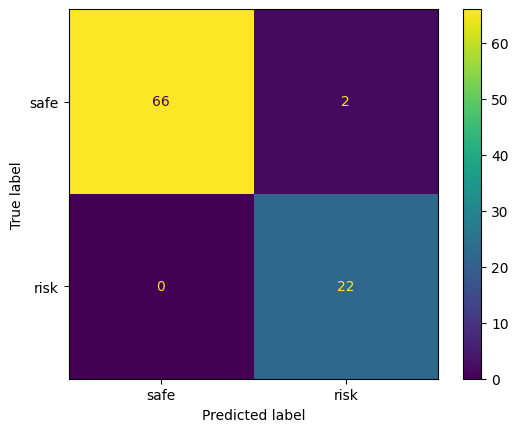

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(Y_test, Y_pred) # computes confusion matrix
display = ConfusionMatrixDisplay(cm, display_labels=['safe','risk']) # creates confusion matrix
display.plot() # data is simulated so XGBoost should perfectly learn the threshold rules and achieve perfect classification

ROC Curve - Plots False Positives (Fraction of the safe readigns that were marked as safe) against True Positives (Fraction of the risky readings that were marked as risky) as you vary the assignment probability threshold. An AUC (Area under the curve) score is used where 1 = perfect model and 0.5 = guess as singular metric for model quality.

AUC Score: 1.0


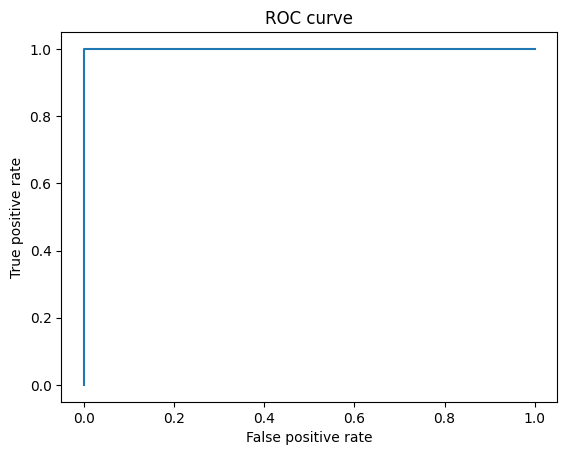

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(Y_test, Y_prob) #false positive rate, true positive rate

plt.plot(fpr, tpr)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")


print("AUC Score:", roc_auc_score(Y_test, Y_prob)) #the data is simulated from threshold rules so will be one when simulated

Finally we will produce a SHAP summary plot, which indicates how much each metric influenced the prediction of risk (positive indicates pushed towards).

C:\Users\44748\AppData\Local\Temp\ipykernel_9688\217402474.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test) #for simulated data this just indicates which threshold rules chosen were harshest


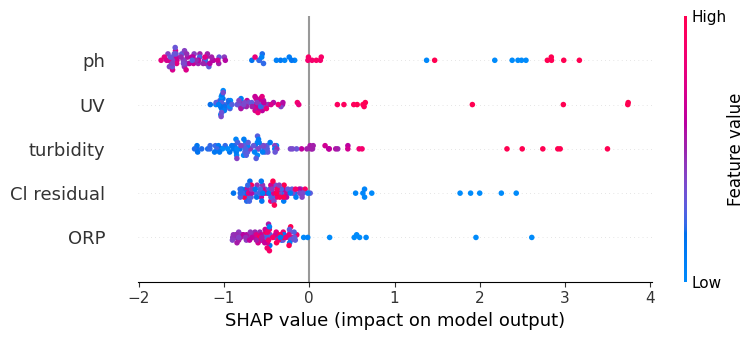

In [31]:
import shap

explainer = shap.TreeExplainer(model) # interprets the feature importance and contributions to the predictions
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test) #for simulated data this just indicates which threshold rules chosen were harshest

## 5. Edge Deployment — Model Conversion to C

- Store the trained model to JSON
- Convert the model to C code using m2cgen
- The output C file can be compiled and deployed to a microcontroller for local inference with no internet connection
- A snippet of the decision tree logic is printed to demonstrate human-readable C output

In [32]:
# Unncessary for the compression step but can be useful to understand tree structure
import json

model.save_model('model.json') # saves the trained XGBoost model in JSON format

with open('model.json','r') as file:
    content = json.load(file) # opens it up so it can be read and printed

lines = json.dumps(content, indent=2)

#print(lines[0:850]) #- beginning of tree details shown
#print(lines[78680:80950]) #- tree number 28 shown


In [33]:
import m2cgen as thisbetterwork # library quickly converts the trained XGBoost model into C code for deployment

code = thisbetterwork.export_to_c(model) # the actual conversion step

print(code[250:1000]) # shows one tree for inspection

with open('water_quality_edge.c','w') as file: # writes the generated C code to a file 
    file.write(code)

if (input[3] < 0.49010453) {
        if (input[0] < 7.528561) {
            if (input[1] < 23.513678) {
                var0 = -0.1689008;
            } else {
                var0 = 0.40444446;
            }
        } else {
            var0 = 0.40219784;
        }
    } else {
        var0 = 0.4777778;
    }
    double var1;
    if (input[3] < 0.49971524) {
        if (input[0] < 7.761515) {
            if (input[0] < 6.2990746) {
                var1 = 0.3787412;
            } else {
                var1 = -0.10414324;
            }
        } else {
            var1 = 0.3613395;
        }
    } else {
        var1 = 0.38823482;
    }
    double var2;
    if (input[3] < 0.49971524) {
        if (input[1] < 23.513678) {
            if (inp
